In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 폰트 설정: 한글 깨짐을 방지하기 위해
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # - 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 200

In [3]:
cali_df = pd.read_csv('data\california.csv')
cali_df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [4]:
cali_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
cali_df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


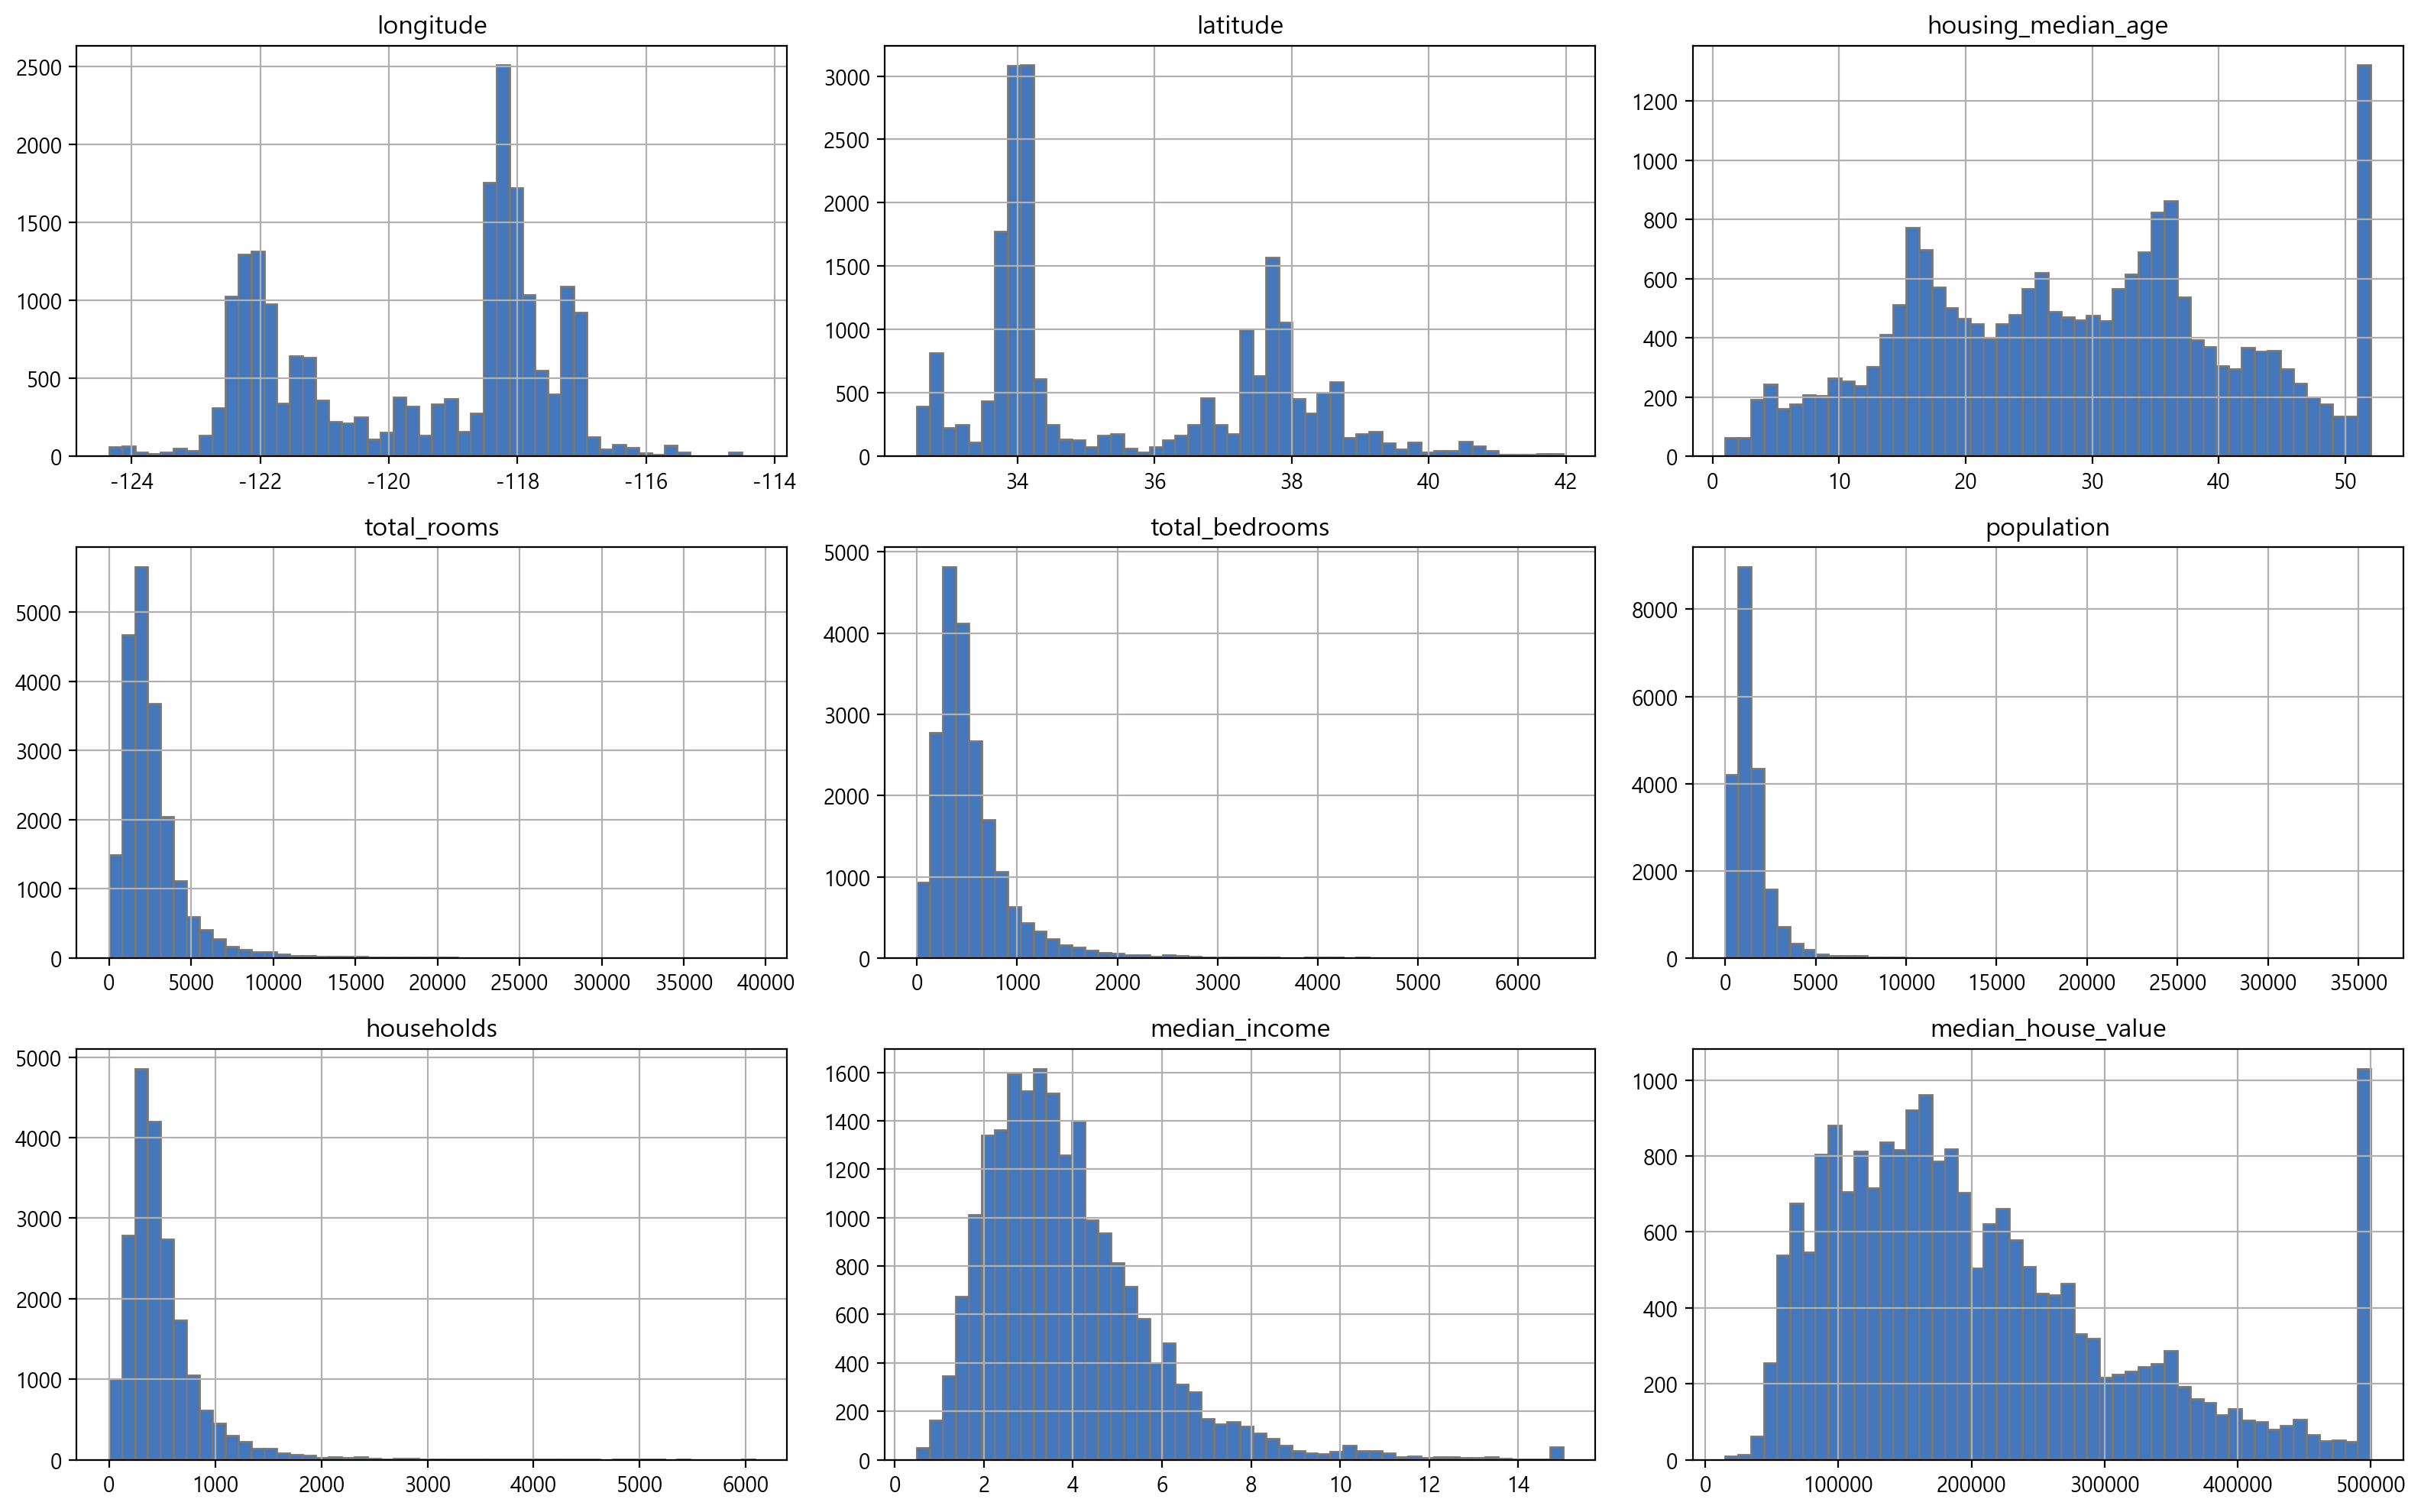

In [6]:
# 시각적 데이터 한번에 파악하기
cali_df.hist(bins=50, figsize=(16,10), color='#4477bb', edgecolor='#777777')
plt.tight_layout()
plt.show()

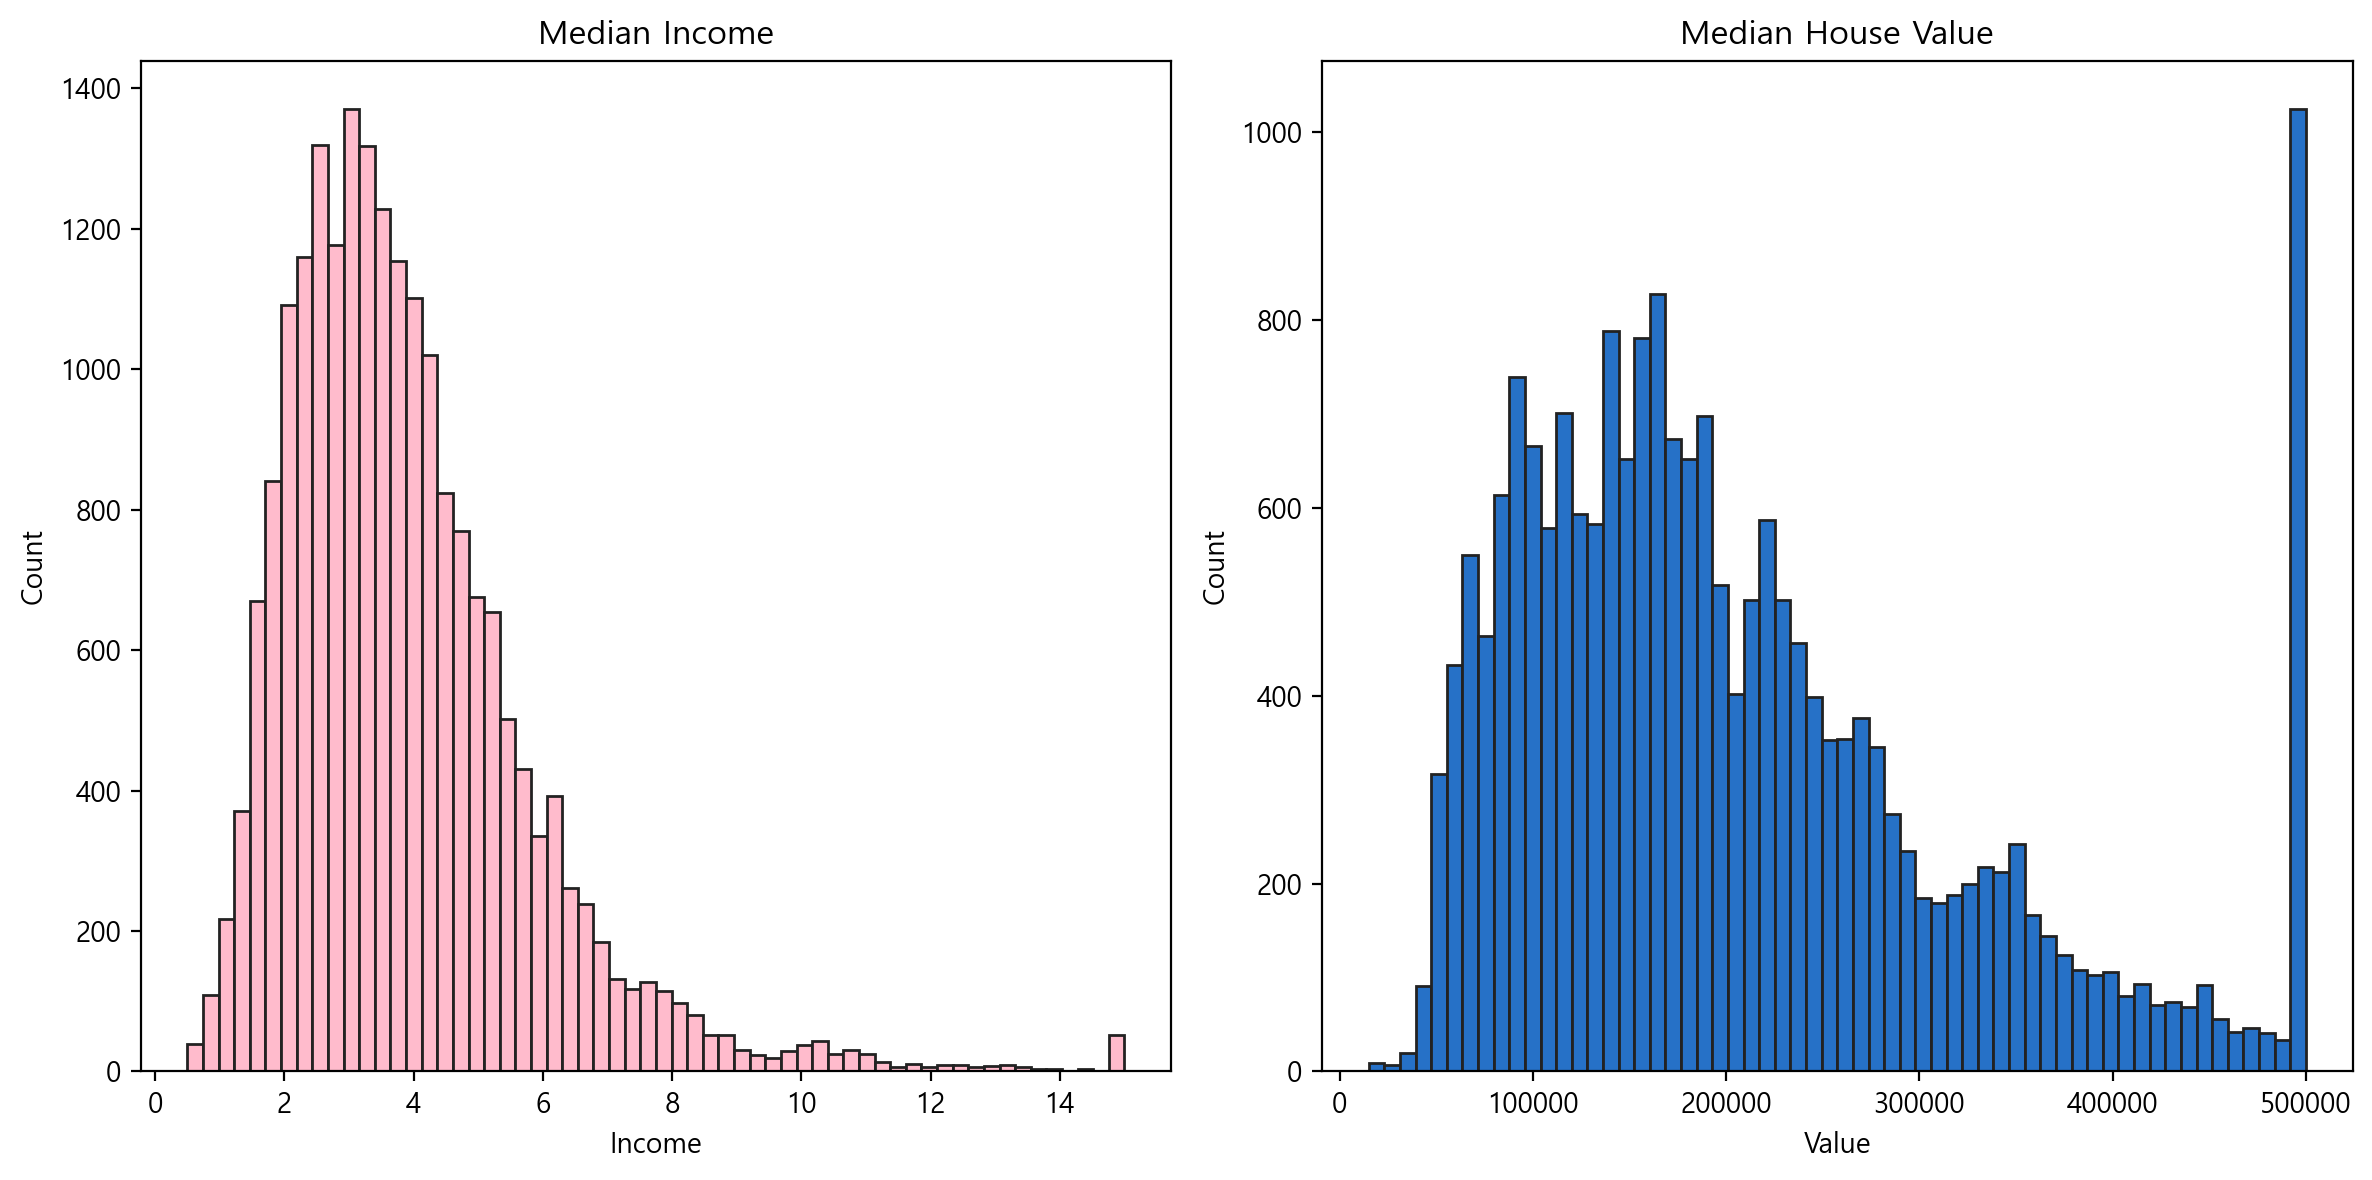

In [7]:
# median income vs median house value의 분포 확인하기

fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].hist(cali_df['median_income'], bins=60, color='#ffbbcc', edgecolor="#222222")
axes[0].set_title('Median Income')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')

axes[1].hist(cali_df['median_house_value'], bins=60, color="#2671c7", edgecolor="#222222")
axes[1].set_title('Median House Value')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

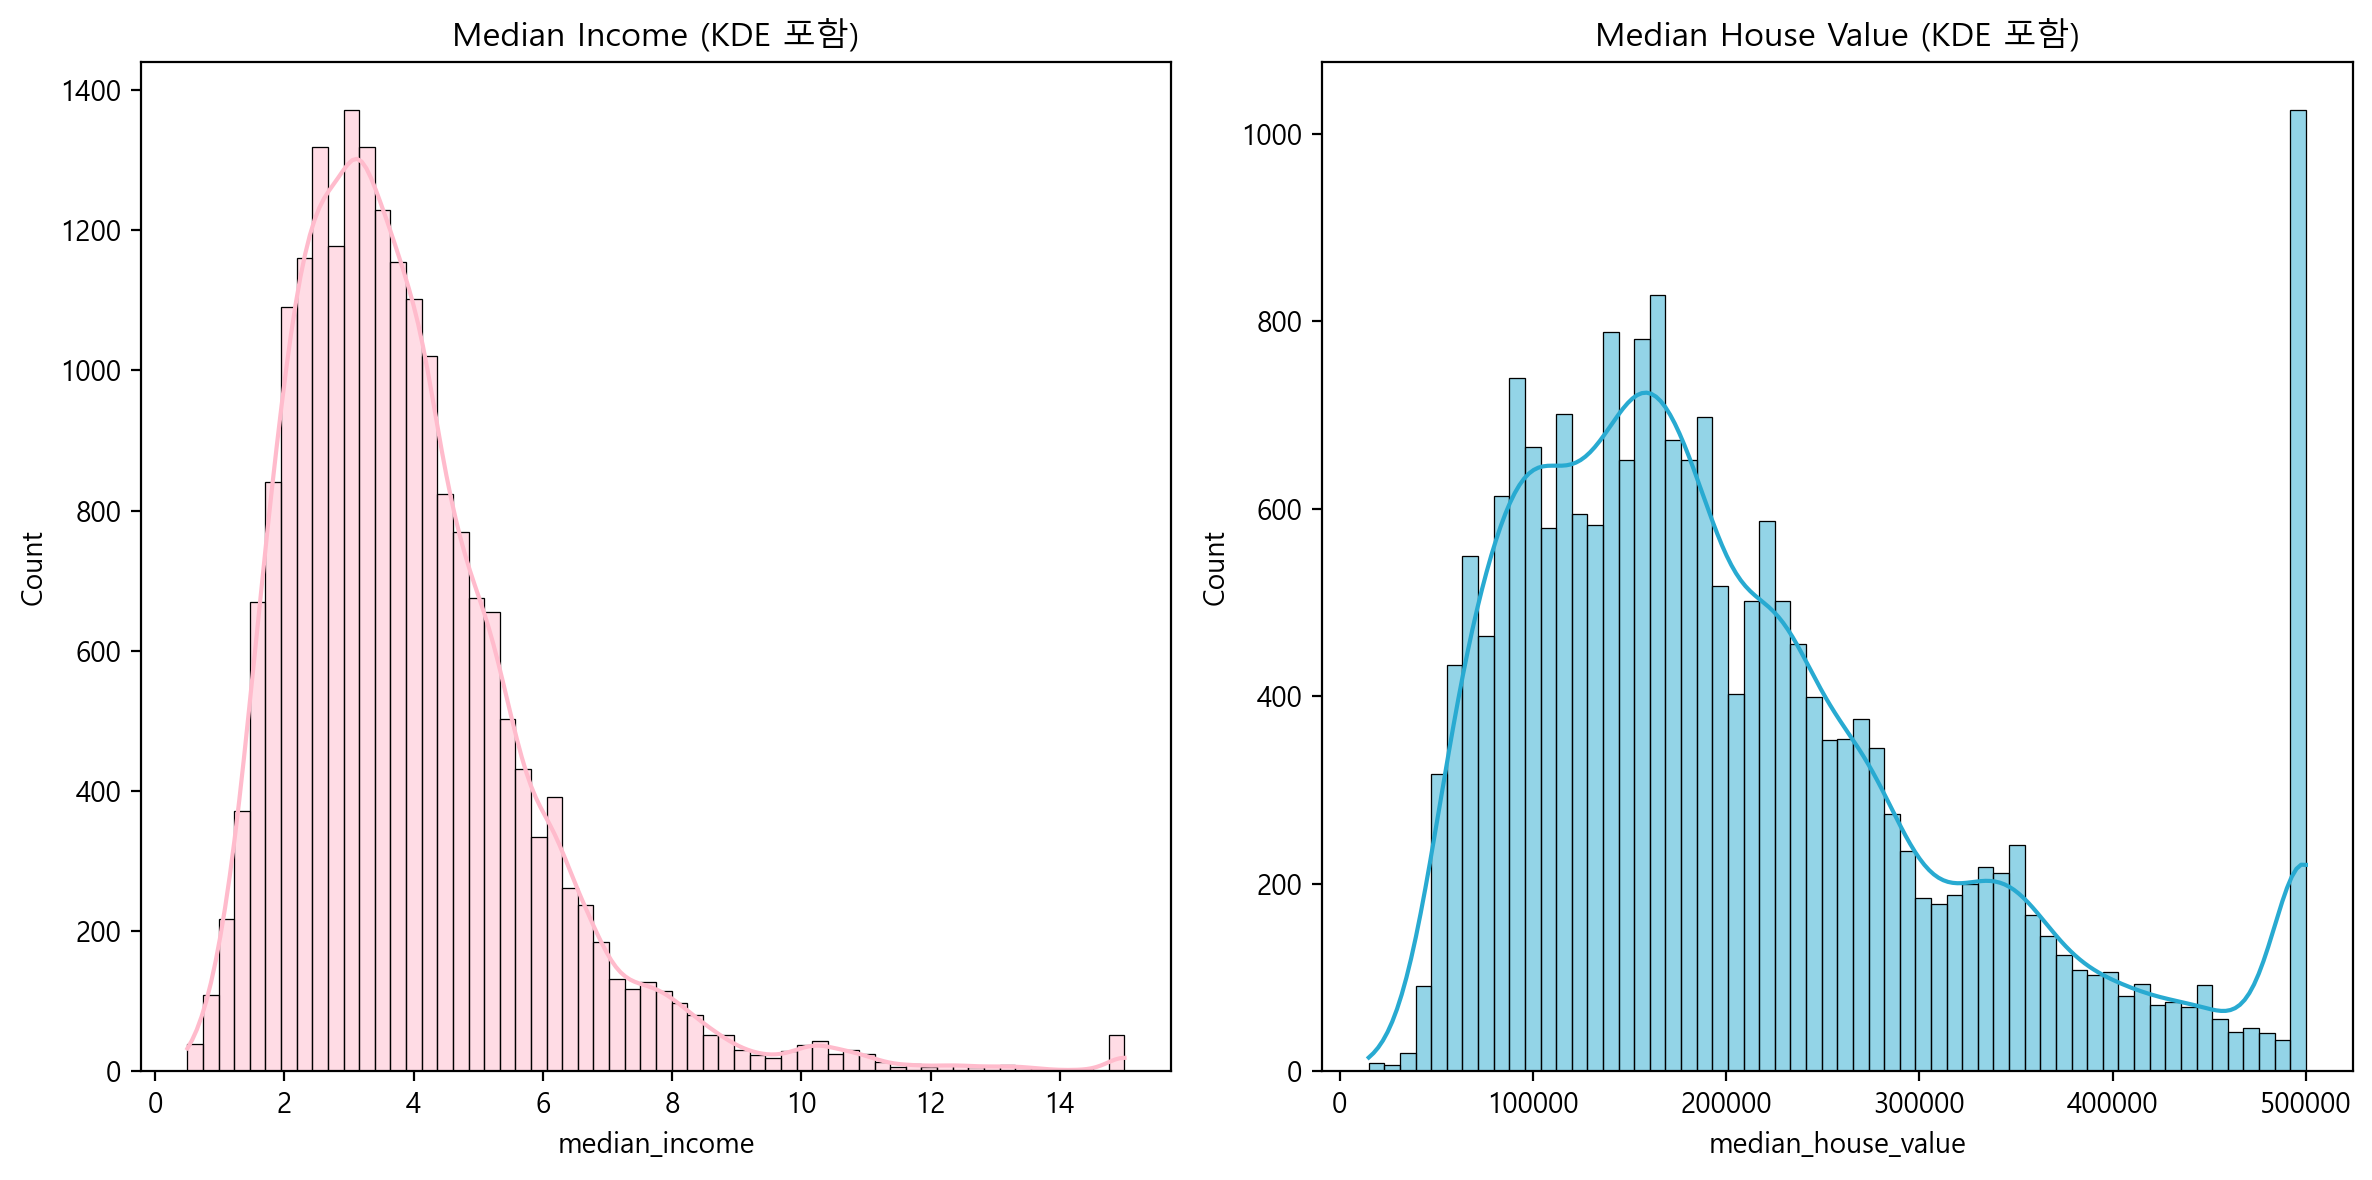

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(cali_df['median_income'], bins=60, kde=True, color='#ffbbcc', ax=axes[0])
axes[0].set_title('Median Income (KDE 포함)')

sns.histplot(cali_df['median_house_value'], bins=60, kde=True, color="#28aad1", ax=axes[1])
axes[1].set_title('Median House Value (KDE 포함)')
plt.tight_layout()
plt.show()

In [9]:
corr = cali_df.corr()

sns.heatmap(corr,   # 데이터
            annot=True, # 내용
            fmt='.2f',  # 포맷
            cmap='coolwarm',    #컬러맵
            vmin=-1, vmax=1,
            center=0,
            linewidth=0.5,
            annot_kws={'size':5})
plt.title('California House Data Correlation')
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'NEAR BAY'

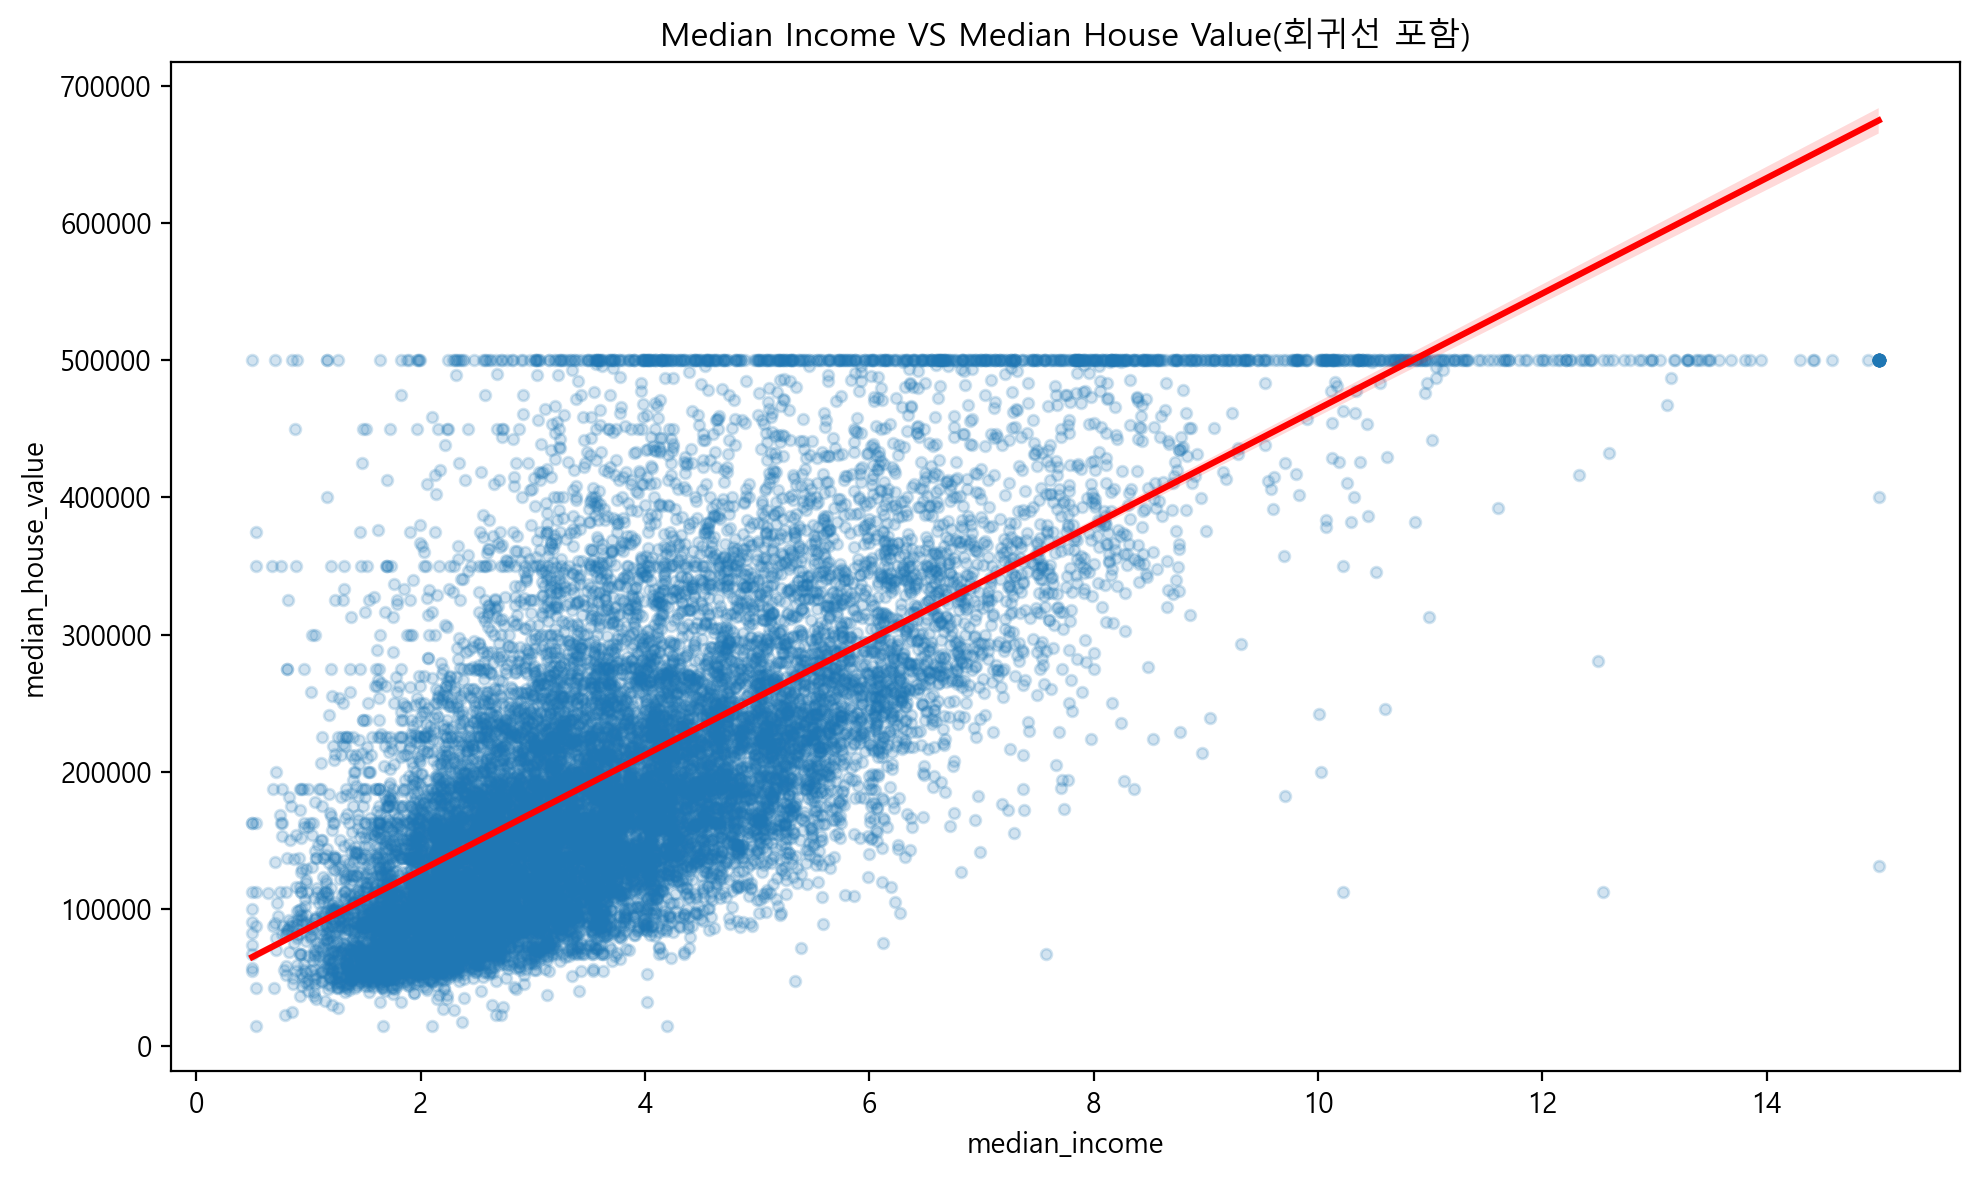

In [ ]:
# 산점도 그리기
plt.figure(figsize=(10, 6))
sns.regplot(data=cali_df, x='median_income', y='median_house_value', scatter_kws={'alpha':0.2, 's':15},
            line_kws={'color':'red'})
plt.title('Median Income VS Median House Value(회귀선 포함)')
plt.tight_layout()
plt.show()

<Figure size 2000x1200 with 0 Axes>

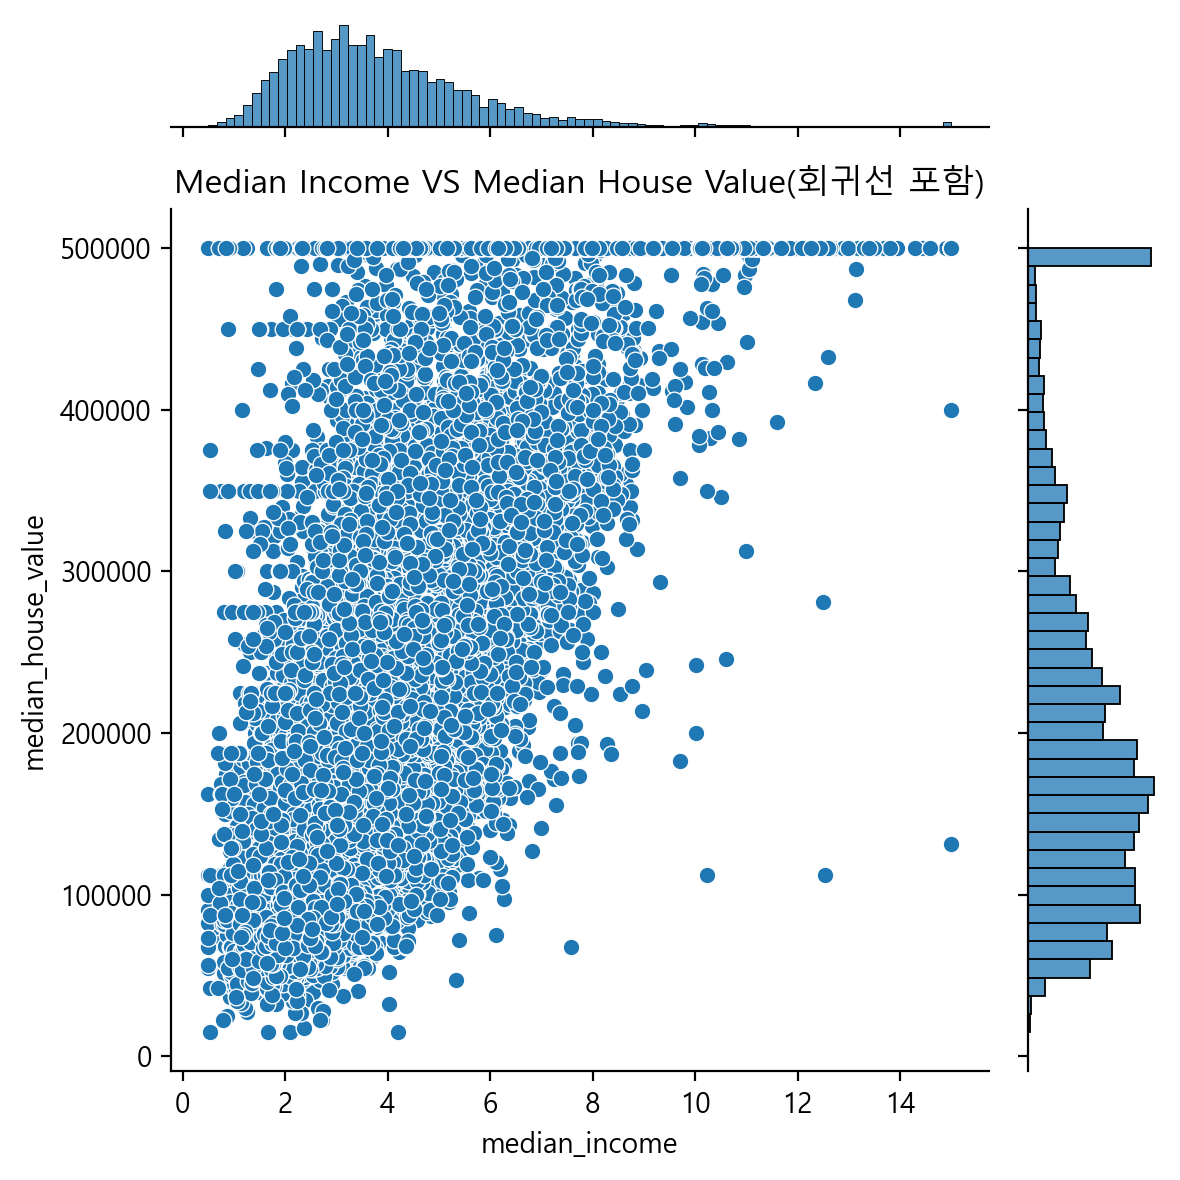

In [ ]:
# jointplot: 산점도와 히스토그램 그래프를 같이 그림
plt.figure(figsize=(10, 6))
sns.jointplot(data=cali_df, x='median_income', y='median_house_value')
plt.title('Median Income VS Median House Value(회귀선 포함)')
plt.tight_layout()
plt.show()